# 02b_LSTM_Meta (V, I, TS, WFR)

02번 파일과 동일한 실험 설계(고정 하이퍼파라미터 + val EarlyStopping)에
폴더명의 **TS(Travel Speed)**, **WFR(Wire Feed Rate)**를 상수 피처로 추가.

| 구분 | Trial | Label |
|---|---|---|
| Train | Test1~43 (44,45 제외) | 0=정상, 1=이상 |
| Validation (EarlyStopping) | Test44, Test45 | 0=정상, 1=이상 |
| Test | Val1, Val2, Val5, Val8, Val9 | 0=정상, 1=이상 |

| 피처 | 정규화 |
|---|---|
| V, I | trial z-score → global scaler |
| TS, WFR | global scaler (raw값, 상수) |

In [1]:
from pathlib import Path

BASE_DIR  = Path.home() / 'Desktop' / 'ai1' / 'original_INC_202501'
MODEL_DIR = Path.home() / 'Desktop' / 'ai1' / 'lstm_meta_model'
MODEL_DIR.mkdir(exist_ok=True)

SENSOR_INTERVAL = 0.1
WINDOW_DURATION = 3.0
STEP_DURATION   = 1.0
WINDOW_SIZE = int(WINDOW_DURATION / SENSOR_INTERVAL)   # 30
STEP_SIZE   = int(STEP_DURATION   / SENSOR_INTERVAL)   # 10
FEATURES    = ['Avg Voltage', 'Avg Current']

NORMAL_TEST_IDS   = {1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 28, 29, 30, 44}
ABNORMAL_TEST_IDS = {6, 31, 45} | set(range(32, 44))
NORMAL_VAL_IDS    = set(range(3, 10))
ABNORMAL_VAL_IDS  = {1, 2}
VAL_TRIAL_IDS     = {44, 45}

LSTM_HIDDEN_1       = 64
LSTM_HIDDEN_2       = 32
DROPOUT_RATE        = 0.3
EPOCHS              = 200
BATCH_SIZE          = 32
LEARNING_RATE       = 1e-3
EARLY_STOP_PATIENCE = 20
RANDOM_SEED         = 42

print(f'WINDOW_SIZE : {WINDOW_SIZE} samples ({WINDOW_DURATION}s)')
print(f'STEP_SIZE   : {STEP_SIZE} samples ({STEP_DURATION}s)')

WINDOW_SIZE : 30 samples (3.0s)
STEP_SIZE   : 10 samples (1.0s)


In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report,
                              roc_auc_score, roc_curve,
                              average_precision_score, precision_recall_curve)

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch :', torch.__version__)
print('Device  :', DEVICE)

PyTorch : 2.11.0+cu128
Device  : cuda


In [3]:
# =========================
# 데이터 로드
# V, I: trial z-score (DC 레벨 제거)
# TS, WFR: 폴더명 파싱 → 상수 열 추가
# =========================

def parse_folder_id(name):
    m = re.match(r'^(Test|Val)(\d+)_', name, flags=re.IGNORECASE)
    if not m: return None, None
    return m.group(1).capitalize(), int(m.group(2))

def parse_meta(name):
    m = re.search(r'_(\d+)TS_(\d+)WFR', name, re.IGNORECASE)
    if not m: return None, None
    return float(m.group(1)), float(m.group(2))

def get_label(prefix, idx):
    if prefix == 'Test':
        if idx in NORMAL_TEST_IDS:   return 0
        if idx in ABNORMAL_TEST_IDS: return 1
    elif prefix == 'Val':
        if idx in NORMAL_VAL_IDS:    return 0
        if idx in ABNORMAL_VAL_IDS:  return 1
    raise ValueError(f'라벨 매핑 없음: {prefix}{idx}')

def get_split(prefix, idx):
    if prefix == 'Val':          return 'test'
    if prefix == 'Test':
        if idx in VAL_TRIAL_IDS: return 'val'
        return 'train'
    raise ValueError()

records = []
for d in sorted(BASE_DIR.iterdir()):
    if not d.is_dir(): continue
    prefix, idx = parse_folder_id(d.name)
    if prefix is None: continue
    ts, wfr = parse_meta(d.name)
    if ts is None:
        print(f'[SKIP] TS/WFR 파싱 실패: {d.name}'); continue
    try:
        label = get_label(prefix, idx)
        split = get_split(prefix, idx)
    except ValueError as e:
        print(f'[SKIP] {d.name}: {e}'); continue
    csvs = list(d.glob('*.csv'))
    if not csvs: continue

    vi = pd.read_csv(csvs[0])[FEATURES].astype(float).values
    mean, std = vi.mean(0), vi.std(0)
    std[std < 1e-8] = 1e-8
    vi_norm = (vi - mean) / std

    n = len(vi_norm)
    data = np.hstack([
        vi_norm,
        np.full((n, 1), ts,  dtype=np.float64),
        np.full((n, 1), wfr, dtype=np.float64),
    ]).astype(np.float32)

    records.append({'folder': d.name, 'label': label, 'split': split,
                    'data': data, 'ts': ts, 'wfr': wfr})
    print(f'{d.name:45s}  split={split:5s}  label={label}'
          f'  TS={int(ts):2d}  WFR={int(wfr):3d}  rows={n}')

summary = pd.DataFrame([{k: r[k] for k in ('folder','split','label','ts','wfr')}
                         for r in records])
print('\n=== Split 요약 ===')
print(summary.groupby(['split','label']).size().rename('n_trials'))

Test1_160A_20TS_160WFR                         split=train  label=0  TS=20  WFR=160  rows=388
Test2_160A_20TS_190WFR                         split=train  label=0  TS=20  WFR=190  rows=386
Test31_120A_20TS_160WFR                        split=train  label=1  TS=20  WFR=160  rows=401
Test32_120A_20TS_190WFR                        split=train  label=1  TS=20  WFR=190  rows=407
Test34_120A_30TS_190WFR                        split=train  label=1  TS=30  WFR=190  rows=274
Test38_140A_30TS_180WFR                        split=train  label=1  TS=30  WFR=180  rows=280
Test3_160A_30TS_160WFR                         split=train  label=0  TS=30  WFR=160  rows=261
Test41_140A_25TS_180WFR                        split=train  label=1  TS=25  WFR=180  rows=329
Test43_150A_30TS_190WFR                        split=train  label=1  TS=30  WFR=190  rows=260
Test44_150A_25TS_160WFR                        split=val    label=0  TS=25  WFR=160  rows=313
Test45_150A_25TS_180WFR                        split=val    

In [4]:
# =========================
# 슬라이딩 윈도우 생성
# =========================

def make_windows(data, ws, ss):
    return np.stack([data[s:s+ws] for s in range(0, len(data)-ws+1, ss)])

buckets = {'train': ([], []), 'val': ([], []), 'test': ([], [])}
for r in records:
    wins   = make_windows(r['data'], WINDOW_SIZE, STEP_SIZE)
    labels = np.full(len(wins), r['label'], dtype=np.float32)
    buckets[r['split']][0].append(wins)
    buckets[r['split']][1].append(labels)
    print(f'{r["folder"]:45s}  {r["split"]:5s}  windows={len(wins)}')

X = {s: np.vstack(buckets[s][0]).astype(np.float32) for s in buckets}
y = {s: np.concatenate(buckets[s][1]) for s in buckets}

FEAT_NAMES = ['V', 'I', 'TS', 'WFR']
n_feat = X['train'].shape[2]   # 4

print('\n=== 윈도우 개수 ===')
for s in ('train', 'val', 'test'):
    u, c = np.unique(y[s], return_counts=True)
    cnt  = dict(zip(u.astype(int), c))
    print(f'{s:5s}  total={len(y[s]):5d}  normal={cnt.get(0,0):5d}  abnormal={cnt.get(1,0):5d}')

Test1_160A_20TS_160WFR                         train  windows=36
Test2_160A_20TS_190WFR                         train  windows=36
Test31_120A_20TS_160WFR                        train  windows=38
Test32_120A_20TS_190WFR                        train  windows=38
Test34_120A_30TS_190WFR                        train  windows=25
Test38_140A_30TS_180WFR                        train  windows=26
Test3_160A_30TS_160WFR                         train  windows=24
Test41_140A_25TS_180WFR                        train  windows=30
Test43_150A_30TS_190WFR                        train  windows=24
Test44_150A_25TS_160WFR                        val    windows=29
Test45_150A_25TS_180WFR                        val    windows=29
Test5_160A_40TS_160WFR                         train  windows=17
Test7_180A_20TS_160WFR                         train  windows=35
Test8_180A_20TS_190WFR                         train  windows=35
Val1_130A_22TS_170WFR                          test   windows=24
Val2_130A_24TS_200WFR    

In [5]:
# =========================
# 글로벌 StandardScaler (V, I, TS, WFR 전부)
# =========================

scaler = StandardScaler()
scaler.fit(X['train'].reshape(-1, n_feat))

def scale(arr):
    n, w, f = arr.shape
    return scaler.transform(arr.reshape(-1, f)).reshape(n, w, f).astype(np.float32)

Xs = {s: scale(X[s]) for s in X}

print('=== 글로벌 스케일러 통계 (train 기준) ===')
for i, name in enumerate(FEAT_NAMES):
    print(f'  {name:5s}  mean={scaler.mean_[i]:+9.4f}  std={scaler.scale_[i]:.4f}')
print(f'\nX_train : {Xs["train"].shape}')
print(f'X_val   : {Xs["val"].shape}')
print(f'X_test  : {Xs["test"].shape}')

=== 글로벌 스케일러 통계 (train 기준) ===
  V      mean=  +0.0204  std=0.6635
  I      mean=  +0.0815  std=0.2982
  TS     mean= +24.0659  std=5.6043
  WFR    mean=+176.0989  std=13.8933

X_train : (364, 30, 4)
X_val   : (58, 30, 4)
X_test  : (150, 30, 4)


In [6]:
# =========================
# PyTorch Dataset / DataLoader
# =========================

class WindowDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)
    def __len__(self):        return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

train_loader = DataLoader(WindowDataset(Xs['train'], y['train']),
                           batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(WindowDataset(Xs['val'],   y['val']),
                           batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(WindowDataset(Xs['test'],  y['test']),
                           batch_size=BATCH_SIZE, shuffle=False)

print(f'Train batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')
print(f'Test  batches : {len(test_loader)}')

Train batches : 12
Val   batches : 2
Test  batches : 5


In [7]:
# =========================
# LSTM 모델 정의
# =========================

class LSTMAnomalyDetector(nn.Module):
    def __init__(self, n_features, hidden1, hidden2, dropout):
        super().__init__()
        self.lstm1 = nn.LSTM(n_features, hidden1, batch_first=True)
        self.drop1 = nn.Dropout(dropout)
        self.lstm2 = nn.LSTM(hidden1, hidden2, batch_first=True)
        self.drop2 = nn.Dropout(dropout)
        self.fc    = nn.Linear(hidden2, 1)

    def forward(self, x):
        out, _ = self.lstm1(x);  out = self.drop1(out)
        out, _ = self.lstm2(out)
        return torch.sigmoid(self.fc(self.drop2(out[:, -1, :]))).squeeze(-1)


model     = LSTMAnomalyDetector(n_feat, LSTM_HIDDEN_1, LSTM_HIDDEN_2, DROPOUT_RATE).to(DEVICE)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nn_features      : {n_feat}  {FEAT_NAMES}')
print(f'Trainable params: {total_params:,}')

LSTMAnomalyDetector(
  (lstm1): LSTM(4, 64, batch_first=True)
  (drop1): Dropout(p=0.3, inplace=False)
  (lstm2): LSTM(64, 32, batch_first=True)
  (drop2): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

n_features      : 4  ['V', 'I', 'TS', 'WFR']
Trainable params: 30,497


In [8]:
# =========================
# 학습 루프 (val loss 기준 EarlyStopping, patience=20)
# =========================

best_val_loss    = float('inf')
patience_counter = 0
best_model_path  = str(MODEL_DIR / 'best_lstm.pt')
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}


def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, total_correct, total_n = 0.0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for Xb, yb in loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            if train: optimizer.zero_grad()
            pred = model(Xb)
            loss = criterion(pred, yb)
            if train: loss.backward(); optimizer.step()
            total_loss    += loss.item() * len(yb)
            total_correct += ((pred >= 0.5).float() == yb).sum().item()
            total_n       += len(yb)
    return total_loss / total_n, total_correct / total_n


for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    vl_loss, vl_acc = run_epoch(val_loader,   train=False)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{EPOCHS}  '
              f'train_loss={tr_loss:.4f}  train_acc={tr_acc:.4f}  '
              f'val_loss={vl_loss:.4f}  val_acc={vl_acc:.4f}')

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss; patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f'\nEarly stopping at epoch {epoch}  best_val_loss={best_val_loss:.4f}')
            break

model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
print(f'\n학습 완료  best_val_loss={best_val_loss:.4f}')

Epoch   1/200  train_loss=0.6923  train_acc=0.5027  val_loss=0.6747  val_acc=0.5000
Epoch  10/200  train_loss=0.3972  train_acc=0.7912  val_loss=0.0377  val_acc=1.0000
Epoch  20/200  train_loss=0.3479  train_acc=0.7967  val_loss=0.0239  val_acc=1.0000
Epoch  30/200  train_loss=0.2583  train_acc=0.8764  val_loss=0.2803  val_acc=0.9138
Epoch  40/200  train_loss=0.1129  train_acc=0.9698  val_loss=0.0025  val_acc=1.0000
Epoch  50/200  train_loss=0.0399  train_acc=0.9835  val_loss=0.0016  val_acc=1.0000
Epoch  60/200  train_loss=0.0085  train_acc=0.9973  val_loss=0.0009  val_acc=1.0000
Epoch  70/200  train_loss=0.0454  train_acc=0.9890  val_loss=0.0006  val_acc=1.0000
Epoch  80/200  train_loss=0.0080  train_acc=0.9945  val_loss=0.0012  val_acc=1.0000
Epoch  90/200  train_loss=0.0012  train_acc=1.0000  val_loss=0.0025  val_acc=1.0000
Epoch 100/200  train_loss=0.0008  train_acc=1.0000  val_loss=0.0116  val_acc=1.0000

Early stopping at epoch 103  best_val_loss=0.0005

학습 완료  best_val_loss=0.0

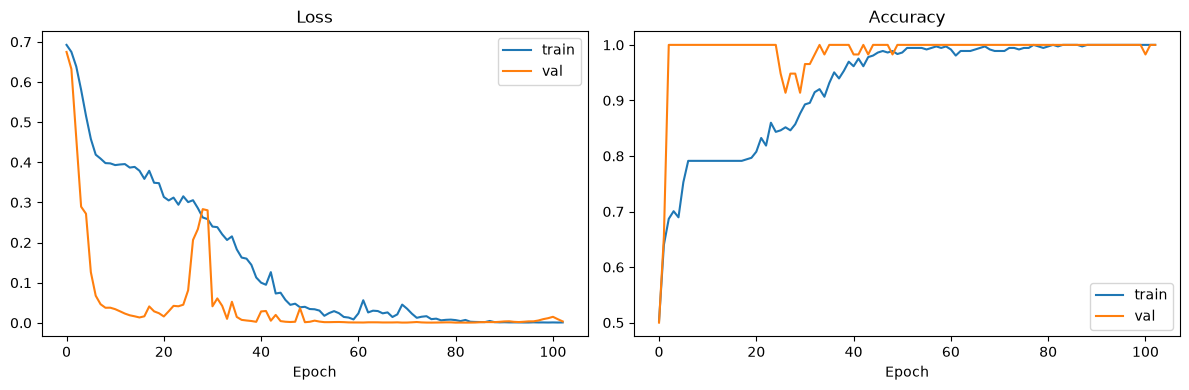

In [9]:
# =========================
# 학습 곡선
# =========================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='train')
axes[0].plot(history['val_loss'],   label='val')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history['train_acc'], label='train')
axes[1].plot(history['val_acc'],   label='val')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()

plt.tight_layout()
plt.savefig(str(MODEL_DIR / 'training_curve.png'), dpi=150)
plt.show()

=== Window-level Evaluation (threshold=0.5) ===
              precision    recall  f1-score   support

   Normal(0)       0.62      0.86      0.72        95
 Abnormal(1)       0.24      0.07      0.11        55

    accuracy                           0.57       150
   macro avg       0.43      0.47      0.42       150
weighted avg       0.48      0.57      0.50       150

ROC-AUC : 0.5828
PR-AUC  : 0.3974


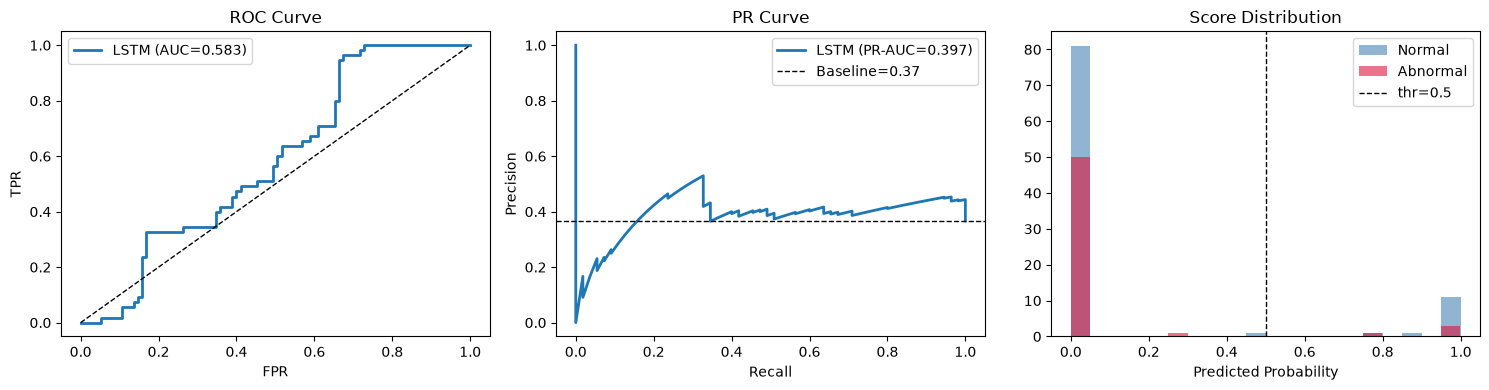

In [10]:
# =========================
# Window-level 평가 (threshold=0.5 고정)
# =========================

model.eval()
all_prob, all_true = [], []
with torch.no_grad():
    for Xb, yb in test_loader:
        all_prob.append(model(Xb.to(DEVICE)).cpu().numpy())
        all_true.append(yb.numpy())

y_prob = np.concatenate(all_prob)
y_true = np.concatenate(all_true).astype(int)
y_pred = (y_prob >= 0.5).astype(int)

roc_auc = roc_auc_score(y_true, y_prob)
pr_auc  = average_precision_score(y_true, y_prob)

print('=== Window-level Evaluation (threshold=0.5) ===')
print(classification_report(y_true, y_pred,
                             target_names=['Normal(0)', 'Abnormal(1)'],
                             zero_division=0))
print(f'ROC-AUC : {roc_auc:.4f}')
print(f'PR-AUC  : {pr_auc:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

fpr, tpr, _ = roc_curve(y_true, y_prob)
axes[0].plot(fpr, tpr, lw=2, label=f'LSTM (AUC={roc_auc:.3f})')
axes[0].plot([0,1],[0,1],'k--',lw=1)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curve'); axes[0].legend()

pre, rec, _ = precision_recall_curve(y_true, y_prob)
baseline = y_true.mean()
axes[1].plot(rec, pre, lw=2, label=f'LSTM (PR-AUC={pr_auc:.3f})')
axes[1].axhline(baseline, color='k', linestyle='--', lw=1, label=f'Baseline={baseline:.2f}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('PR Curve'); axes[1].legend()

axes[2].hist(y_prob[y_true==0], bins=20, alpha=0.6, label='Normal',   color='steelblue')
axes[2].hist(y_prob[y_true==1], bins=20, alpha=0.6, label='Abnormal', color='crimson')
axes[2].axvline(0.5, color='k', linestyle='--', lw=1, label='thr=0.5')
axes[2].set_xlabel('Predicted Probability')
axes[2].set_title('Score Distribution'); axes[2].legend()

plt.tight_layout()
plt.savefig(str(MODEL_DIR / 'window_eval.png'), dpi=150)
plt.show()

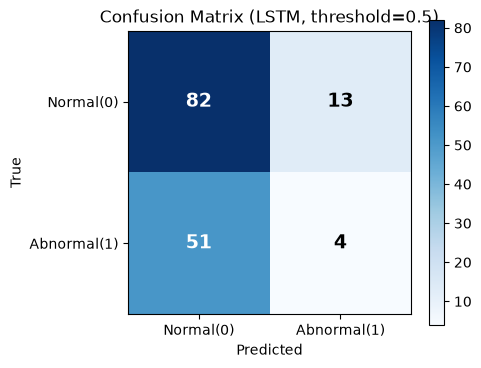

In [11]:
# =========================
# 혼동행렬
# =========================

import itertools
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
fig.colorbar(im, ax=ax)
ax.set(xticks=[0, 1], yticks=[0, 1],
       xticklabels=['Normal(0)', 'Abnormal(1)'],
       yticklabels=['Normal(0)', 'Abnormal(1)'],
       xlabel='Predicted', ylabel='True',
       title='Confusion Matrix (LSTM, threshold=0.5)')
thresh = cm.max() / 2
for i, j in itertools.product(range(2), range(2)):
    ax.text(j, i, f'{cm[i, j]}', ha='center', va='center',
            color='white' if cm[i, j] > thresh else 'black',
            fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(str(MODEL_DIR / 'confusion_matrix.png'), dpi=150)
plt.show()